# Dumper Fuel Consumption Prediction — Final Pipeline
Run cells top to bottom. Each cell explains what it does and why.

## Cell 0 — Install Dependencies (run once on Colab)

In [2]:
# Run this cell first on a fresh Colab session.
# Step 1: install packages not pre-installed on Colab
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'geopandas', 'fiona', 'pyproj', 'lightgbm', 'pyarrow', 'kaggle'], check=True)

# Step 2: set up Kaggle credentials using your username + API key
# Find these at kaggle.com → Your profile → Settings → API section
import kagglehub

kagglehub.login()

mindshift_path = kagglehub.competition_download('mindshift-analytics-haul-mark-challenge')

print('Data source import complete.')
print(mindshift_path)

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


100%|██████████| 1.33G/1.33G [00:15<00:00, 90.4MB/s]

Extracting files...


Data source import complete.
/root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge
/root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge.complete
/root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge/telemetry_2026-01-01_2026-01-10.parquet
/root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge/telemetry_2026-01-21_2026-01-31.parquet
/root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge/mine_001_anonymized.gpkg
/root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge/smry_jan_train_ordered.csv
/root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge/telemetry_2026-02-21_2026-02-28.parquet
/root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge/rfid_refuels_2026-01-01_2026-03-31.parquet
/root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge/telemetry_2026-02-01_2026-02-10.parquet
/root/.cache/kagglehub/

## Cell 1 — Imports & Config

In [3]:
import os, gc, datetime, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import geopandas as gpd
import fiona
from shapely.geometry import Point
from shapely.ops import unary_union
from pyproj import Transformer
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ── Base path — data was downloaded to here by Cell 0 ───────────────────────
BASE = mindshift_path

# ── Telemetry files ──────────────────────────────────────────────────────────
# 4 TRAIN files (39 cols — include DPR targets)
TRAIN_FILES = [
    f'{BASE}/telemetry_2026-01-01_2026-01-10.parquet',
    f'{BASE}/telemetry_2026-01-11_2026-01-20.parquet',
    f'{BASE}/telemetry_2026-02-01_2026-02-10.parquet',
    f'{BASE}/telemetry_2026-02-11_2026-02-20.parquet',
]
# 2 TEST files (31 cols — no DPR targets, no fuel_volume)
TEST_FILES = [
    f'{BASE}/telemetry_2026-01-21_2026-01-31.parquet',
    f'{BASE}/telemetry_2026-02-21_2026-02-28.parquet',
]

GPKG_FILES  = [
    f'{BASE}/mine_001_anonymized.gpkg',
    f'{BASE}/mine_002_anonymized.gpkg',
]
REFUEL_PATH     = f'{BASE}/rfid_refuels_2026-01-01_2026-02-28.parquet'
SUBMISSION_PATH = 'submission.csv'

# ── Only load the columns we actually use downstream ─────────────────────────
# This is the primary RAM fix. Parquet reads only requested columns from disk.
# 31 common columns that exist in both train and test files.
# DPR target columns are loaded separately from train files only.
COMMON_COLS = [
    'vehicle', 'ts', 'mine_anon',
    'latitude', 'longitude', 'altitude',
    'speed', 'ignition',
    'analog_input_1', 'disthav',
    'shift_dpr', 'date_dpr', 'operator_id',
]
# These only exist in train files (39-col versions)
DPR_TARGET_COLS = [
    'fuel_volume',
    'hmr_dpr', 'prod_hr_dpr', 'idle_hr_dpr',
    'maint_hr_dpr', 'bd_hr_dpr', 'km_dpr', 'tonnage',
]

# ── Thresholds ───────────────────────────────────────────────────────────────
DUMP_SIGNAL_THRESHOLD  = 2.5    # analog_input_1 > this = dump event
SPEED_MOVING_KMH       = 2.0    # speed > this = truck moving
ZONE_BUFFER_METRES     = 30     # line boundary → polygon strip width
REFUEL_ZERO_WINDOW_MIN = 5      # minutes: if a 0L refuel is followed by
                                #          a real one within this window,
                                #          drop the 0L event

# ── Coordinate transformer: GPS (WGS84) → mine map (UTM EPSG:32645) ─────────
TRANSFORMER = Transformer.from_crs('EPSG:4326', 'EPSG:32645', always_xy=True)

# ── Operational day: 22:00 prev day → 21:59 current day ─────────────────────
def op_day(ts_series):
    return (ts_series - pd.Timedelta(hours=22)).dt.date

print('Config done.')

Config done.


## Cell 2 — Load Telemetry (RAM-Safe, One File at a Time)

In [4]:
# ── Why this was crashing ────────────────────────────────────────────────────
# Previous approach: read all 6 files fully into RAM, then concat.
# Peak RAM = sum of all 6 files × 2 (concat makes a copy) ≈ 6-8 GB → OOM.
#
# Fix — three layers of reduction, applied per file before any concat:
#   1. Column pruning  — pyarrow only decodes columns we ask for (50-70% RAM cut)
#   2. dtype downcast  — float64→float32, int64→int16 where safe (40% more cut)
#   3. Immediate del   — each raw chunk freed before next file loads
# Result: peak RAM ≈ largest single file + growing concat, well within 12 GB.

DOWNCAST_MAP = {
    'latitude': 'float32', 'longitude': 'float32',
    'altitude': 'float32', 'speed': 'float32',
    'disthav':  'float32', 'analog_input_1': 'float32',
    'ignition': 'int8',
}

def load_parquet_lean(path, extra_cols=None):
    """
    Load a parquet file reading only the columns we need.
    extra_cols: additional columns to load beyond COMMON_COLS (e.g. DPR targets)
    Returns a lean DataFrame with op_day already assigned.
    """
    want = COMMON_COLS + (extra_cols or [])
    available = pq.ParquetFile(path).schema_arrow.names
    cols = [c for c in want if c in available]

    df = pq.read_table(path, columns=cols).to_pandas()

    # Parse timestamps
    df['ts'] = pd.to_datetime(df['ts'], utc=True).dt.tz_convert('Asia/Kolkata')

    # Downcast numeric columns to save RAM
    for col, dtype in DOWNCAST_MAP.items():
        if col in df.columns:
            df[col] = df[col].astype(dtype)

    # Assign operational day immediately
    df['op_day'] = op_day(df['ts'])

    # Filter to DUMP vehicles only (dumper IDs start with 'DUMP')
    df = df[df['vehicle'].str.startswith('Dump', na=False)].copy()

    return df


# ── Load train files (with DPR target columns) ───────────────────────────────
print('Loading TRAIN files...')
train_chunks = []
for path in TRAIN_FILES:
    fname = Path(path).name
    if not Path(path).exists():
        print(f'  MISSING: {fname} — skipping'); continue
    chunk = load_parquet_lean(path, extra_cols=DPR_TARGET_COLS)
    print(f'  {fname}: {len(chunk):,} rows, {list(chunk.columns)}')
    train_chunks.append(chunk)
    gc.collect()

df = pd.concat(train_chunks, ignore_index=True)
del train_chunks; gc.collect()
df = df.sort_values(['vehicle', 'ts']).reset_index(drop=True)
print(f'Train total: {len(df):,} rows | {df["vehicle"].nunique()} vehicles')

# ── Load test files (no DPR columns) ─────────────────────────────────────────
print('\nLoading TEST files...')
test_chunks = []
for path in TEST_FILES:
    fname = Path(path).name
    if not Path(path).exists():
        print(f'  MISSING: {fname} — skipping'); continue
    chunk = load_parquet_lean(path)   # no DPR cols — they don't exist here
    print(f'  {fname}: {len(chunk):,} rows')
    test_chunks.append(chunk)
    gc.collect()

df_test = pd.concat(test_chunks, ignore_index=True)
del test_chunks; gc.collect()
df_test = df_test.sort_values(['vehicle', 'ts']).reset_index(drop=True)
print(f'Test  total: {len(df_test):,} rows | {df_test["vehicle"].nunique()} vehicles')

print(f'\nTrain columns: {list(df.columns)}')
print(f'Test  columns: {list(df_test.columns)}')
print(f'\nMines in train: {sorted(df["mine_anon"].unique())}')
print(f'Mines in test:  {sorted(df_test["mine_anon"].unique())}')

Loading TRAIN files...
  telemetry_2026-01-01_2026-01-10.parquet: 3,345,221 rows, ['vehicle', 'ts', 'mine_anon', 'latitude', 'longitude', 'altitude', 'speed', 'ignition', 'analog_input_1', 'disthav', 'shift_dpr', 'date_dpr', 'operator_id', 'fuel_volume', 'hmr_dpr', 'prod_hr_dpr', 'idle_hr_dpr', 'maint_hr_dpr', 'bd_hr_dpr', 'km_dpr', 'tonnage', 'op_day']
  telemetry_2026-01-11_2026-01-20.parquet: 3,303,092 rows, ['vehicle', 'ts', 'mine_anon', 'latitude', 'longitude', 'altitude', 'speed', 'ignition', 'analog_input_1', 'disthav', 'shift_dpr', 'date_dpr', 'operator_id', 'fuel_volume', 'hmr_dpr', 'prod_hr_dpr', 'idle_hr_dpr', 'maint_hr_dpr', 'bd_hr_dpr', 'km_dpr', 'tonnage', 'op_day']
  telemetry_2026-02-01_2026-02-10.parquet: 3,602,126 rows, ['vehicle', 'ts', 'mine_anon', 'latitude', 'longitude', 'altitude', 'speed', 'ignition', 'analog_input_1', 'disthav', 'shift_dpr', 'date_dpr', 'operator_id', 'fuel_volume', 'hmr_dpr', 'prod_hr_dpr', 'idle_hr_dpr', 'maint_hr_dpr', 'bd_hr_dpr', 'km_dpr',

## Cell 3 — Load Spatial Data & Build Zone Polygons

In [5]:
# ── GeoPackage layers (from your cmd output) ──────────────────────────────────
#   bench, haul_road, ml_boundary, mineral_stock, nh_road, ob_dump
#
# CRITICAL: All geofences are LINE boundaries, not filled polygons.
# A point can never be "inside" a line — we must buffer lines into
# polygon strips first. ZONE_BUFFER_METRES = 30 means any ping within
# 30 metres of the line boundary counts as being in that zone.
#
# haul_road + ml_boundary + nh_road are NOT zone fences — we load
# haul_road separately for road context but don't use it for zone checks.

ZONE_LAYER_MAP = {
    'bench':         'bench',       # loading zone
    'ob_dump':       'ob_dump',     # overburden dump
    'mineral_stock': 'stock',       # ROM / mineral stockpile
    # cpu / crusher not in your gpkg — add here if present
}

# Map filename → mine_anon value in telemetry
# Check the printed mine IDs from Cell 2 and adjust if needed
GPKG_TO_MINE = {
    'mine_001_anonymized.gpkg': 'mine001',
    'mine_002_anonymized.gpkg': 'mine002',
}

zone_polygons_by_mine = {}
haul_roads_by_mine    = {}

for gpkg_path in GPKG_FILES:
    if not Path(gpkg_path).exists():
        print(f'MISSING: {gpkg_path}'); continue

    gpkg_name = Path(gpkg_path).name
    mine_id   = GPKG_TO_MINE.get(gpkg_name, gpkg_name)
    layers    = fiona.listlayers(gpkg_path)
    print(f'\n{gpkg_name} → mine_anon="{mine_id}"  |  layers: {layers}')

    zone_polys = {}
    for layer_name, zone_label in ZONE_LAYER_MAP.items():
        if layer_name not in layers:
            print(f'  Layer "{layer_name}" not found — skipping'); continue

        gdf = gpd.read_file(gpkg_path, layer=layer_name)

        # Ensure UTM EPSG:32645 (mine map native CRS)
        if gdf.crs is None or gdf.crs.to_epsg() != 32645:
            gdf = gdf.to_crs('EPSG:32645')

        # Buffer line boundaries → polygon strip
        # unary_union merges all features in this layer into one polygon
        buffered = unary_union(gdf.geometry.buffer(ZONE_BUFFER_METRES))
        zone_polys[zone_label] = buffered
        print(f'  Loaded "{layer_name}" → zone "{zone_label}" (buffered {ZONE_BUFFER_METRES}m)')

    zone_polygons_by_mine[mine_id] = zone_polys

    if 'haul_road' in layers:
        hr = gpd.read_file(gpkg_path, layer='haul_road')
        if hr.crs is None or hr.crs.to_epsg() != 32645:
            hr = hr.to_crs('EPSG:32645')
        haul_roads_by_mine[mine_id] = hr
        print(f'  Loaded haul_road ({len(hr)} segments)')

# ── Verify mine IDs match between telemetry and map files ────────────────────
telem_mines = set(df['mine_anon'].unique()) | set(df_test['mine_anon'].unique())
map_mines   = set(zone_polygons_by_mine.keys())
if not telem_mines.issubset(map_mines):
    print(f'\nWARNING: Unmatched mines: {telem_mines - map_mines}')
    print('Update GPKG_TO_MINE in this cell to fix.')
else:
    print(f'\nAll mine IDs matched: {telem_mines}')


mine_001_anonymized.gpkg → mine_anon="mine001"  |  layers: ['bench', 'haul_road', 'ml_boundary', 'mineral_stock', 'nh_road', 'ob_dump']
  Loaded "bench" → zone "bench" (buffered 30m)
  Loaded "ob_dump" → zone "ob_dump" (buffered 30m)
  Loaded "mineral_stock" → zone "stock" (buffered 30m)
  Loaded haul_road (165 segments)

mine_002_anonymized.gpkg → mine_anon="mine002"  |  layers: ['bench', 'cpu', 'ecr', 'haul_road', 'ml_boundary', 'mineral_stock', 'nh_road', 'ob_dump', 'office', 'village_road']
  Loaded "bench" → zone "bench" (buffered 30m)
  Loaded "ob_dump" → zone "ob_dump" (buffered 30m)
  Loaded "mineral_stock" → zone "stock" (buffered 30m)
  Loaded haul_road (129 segments)

All mine IDs matched: {'mine002', 'mine001'}


## Cell 4 — Convert GPS Coords to UTM & Assign Zones

In [6]:
# GPS coords are in WGS84 (degrees). Mine maps are in UTM EPSG:32645 (metres).
# Must convert before any spatial operation.
# Then for every ping, check which buffered zone polygon it falls inside.

def add_utm_and_zones(df, zone_polygons_by_mine):
    df = df.dropna(subset=['latitude', 'longitude']).copy()

    # Coordinate conversion
    x, y = TRANSFORMER.transform(df['longitude'].values, df['latitude'].values)
    df['utm_x'] = x.astype('float32')
    df['utm_y'] = y.astype('float32')

    # Default zone = transit
    df['zone'] = 'transit'

    # Process each mine separately — use that mine's polygons only
    for mine_id, zone_polys in zone_polygons_by_mine.items():
        mine_mask = df['mine_anon'] == mine_id
        mine_rows = df[mine_mask]
        if len(mine_rows) == 0:
            continue

        # Build GeoSeries of points for this mine's rows
        pts = gpd.GeoSeries(
            gpd.points_from_xy(mine_rows['utm_x'], mine_rows['utm_y']),
            crs='EPSG:32645'
        )

        for zone_label, polygon in zone_polys.items():
            in_zone = pts.within(polygon).values
            df.loc[mine_rows.index[in_zone], 'zone'] = zone_label

    return df

print('Converting coords + assigning zones to train...')
df      = add_utm_and_zones(df,      zone_polygons_by_mine)
print('Converting coords + assigning zones to test...')
df_test = add_utm_and_zones(df_test, zone_polygons_by_mine)
gc.collect()

print('\nZone distribution — train:')
print(df['zone'].value_counts())
print('\nZone distribution — test:')
print(df_test['zone'].value_counts())

# Sanity check: if everything is 'transit', buffer is too small or mine IDs don't match
non_transit = (df['zone'] != 'transit').mean()
print(f'\n{non_transit:.1%} of train pings are inside a named zone')
if non_transit < 0.01:
    print('WARNING: <1% in zones — check GPKG_TO_MINE or increase ZONE_BUFFER_METRES')

Converting coords + assigning zones to train...
Converting coords + assigning zones to test...

Zone distribution — train:
zone
bench      5942704
transit    4769636
stock      2967270
ob_dump     525177
Name: count, dtype: int64

Zone distribution — test:
zone
bench      2797608
transit    2243486
stock      1346514
ob_dump     236294
Name: count, dtype: int64

66.4% of train pings are inside a named zone


## Cell 5 — Detect Analog Signal Availability per Dumper

In [7]:
# The dump switch analog signal is available for:
#   - A few dumpers from ~Feb 17
#   - Most dumpers from Mar 1 (outside our data window)
#
# We detect automatically: a dumper 'has' the signal if more than 1%
# of its rows show analog_input_1 > 0.5V (pure noise stays near 0).
#
# This produces a set of vehicle IDs we can use in cycle segmentation.

def detect_dump_switch_vehicles(df):
    if 'analog_input_1' not in df.columns:
        return set()
    sig = (
        df.groupby('vehicle')['analog_input_1']
          .apply(lambda x: (x > 0.5).mean())
    )
    has_switch = set(sig[sig > 0.01].index)
    return has_switch

DUMP_SWITCH_VEHICLES = detect_dump_switch_vehicles(df) | detect_dump_switch_vehicles(df_test)

print(f'Vehicles with active dump switch signal: {len(DUMP_SWITCH_VEHICLES)}')
print(sorted(DUMP_SWITCH_VEHICLES))

Vehicles with active dump switch signal: 12
['Dump012', 'Dump017', 'Dump018', 'Dump019', 'Dump020', 'Dump021', 'Dump023', 'Dump024', 'Dump025', 'Dump026', 'Dump027', 'Dump028']


## Cell 6 — Cycle Segmentation

In [8]:
# Slice each vehicle's telemetry stream into haul cycles.
#
# Tier 1 — dump switch available (detected in Cell 5):
#   analog_input_1 drops from >2.5V back to <2.5V = dump body lowered = cycle end.
#   This is the most accurate signal.
#
# Tier 2 — no dump switch:
#   Truck enters a dump zone (ob_dump / stock) = cycle end.
#   Truck enters bench zone = cycle start.
#   Combined with speed check to reject false zone touches.

DUMP_ZONES  = {'ob_dump', 'stock'}
LOAD_ZONES  = {'bench'}

def segment_cycles_vehicle(grp):
    grp     = grp.copy().reset_index(drop=True)
    vehicle = grp['vehicle'].iloc[0]
    use_switch = vehicle in DUMP_SWITCH_VEHICLES

    cycle_num = 0
    cycle_ids = []

    if use_switch:
        # Tier 1: cycle ends when dump signal falls back below threshold
        is_dumping = (grp['analog_input_1'] > DUMP_SIGNAL_THRESHOLD).fillna(False)
        dump_end   = is_dumping.shift(1, fill_value=False) & ~is_dumping
        for i in range(len(grp)):
            if dump_end.iloc[i]:
                cycle_num += 1
            cycle_ids.append(f'{vehicle}_{cycle_num}')
    else:
        # Tier 2: cycle ends on entry into a dump zone
        # (only count entry if truck was moving beforehand — avoids
        #  counting parked-at-dump-zone rows as new cycles)
        zone       = grp['zone']
        zone_prev  = zone.shift(1, fill_value='transit')
        speed_prev = grp['speed'].shift(1, fill_value=0)
        entered_dump = (
            zone.isin(DUMP_ZONES) &
            ~zone_prev.isin(DUMP_ZONES) &
            (speed_prev > SPEED_MOVING_KMH)
        )
        for i in range(len(grp)):
            if entered_dump.iloc[i]:
                cycle_num += 1
            cycle_ids.append(f'{vehicle}_{cycle_num}')

    grp['cycle_id']         = cycle_ids
    grp['used_dump_switch'] = use_switch
    return grp

print('Segmenting cycles in train...')
df      = df.groupby('vehicle', group_keys=False).apply(segment_cycles_vehicle)
print('Segmenting cycles in test...')
df_test = df_test.groupby('vehicle', group_keys=False).apply(segment_cycles_vehicle)
gc.collect()

print(f'Cycles in train: {df["cycle_id"].nunique():,}')
print(f'Cycles in test:  {df_test["cycle_id"].nunique():,}')

Segmenting cycles in train...
Segmenting cycles in test...
Cycles in train: 77,673
Cycles in test:  42,625


## Cell 7 — Per-Cycle Feature Extraction

In [9]:
# For each cycle compute the features that drive fuel consumption.
# Every feature here has a physical reason to matter:
#   distance       → more km = more fuel
#   net_lift       → climbing heavy = more fuel
#   alt_std        → undulating road = more braking/accel = more fuel
#   idle time      → engine running, wheels not turning = wasted fuel
#   stops_mid_haul → stop-go intensity = more fuel than steady driving
#   mean_speed     → very high speed on a loaded truck = more fuel

def extract_cycle_features(grp):
    # Time gap between consecutive pings in seconds, capped at 120s
    # Cap prevents inflating durations across data gaps
    dt = grp['ts'].diff().dt.total_seconds().clip(0, 120).fillna(0)

    moving   = grp['speed'] > SPEED_MOVING_KMH
    idle     = (grp['speed'] <= SPEED_MOVING_KMH) & (grp['ignition'] == 1)
    at_bench = grp['zone'].isin(LOAD_ZONES)
    at_dump  = grp['zone'].isin(DUMP_ZONES)
    transit  = ~(at_bench | at_dump)

    speed_mv = grp.loc[moving, 'speed']
    alt      = grp['altitude']

    # Dump signal features (only meaningful for Tier 1 dumpers)
    if 'analog_input_1' in grp.columns:
        max_sig        = grp['analog_input_1'].max()
        dump_confirmed = int(float(max_sig) > DUMP_SIGNAL_THRESHOLD)
    else:
        max_sig        = np.nan
        dump_confirmed = 0

    # Stop-go intensity: count transitions moving→stopped during transit
    moving_transit = moving & transit
    stops_mid_haul = int(((~moving_transit) & moving_transit.shift(1, fill_value=False)).sum())

    # Operator ID: take the most common one for this cycle
    op_id = grp['operator_id'].mode()[0] if 'operator_id' in grp.columns and grp['operator_id'].notna().any() else np.nan

    return pd.Series({
        'vehicle':            grp['vehicle'].iloc[0],
        'mine_anon':          grp['mine_anon'].iloc[0],
        'op_day':             grp['op_day'].iloc[0],
        'shift_dpr':          grp['shift_dpr'].iloc[0] if 'shift_dpr' in grp.columns else np.nan,
        'operator_id':        op_id,
        'used_dump_switch':   grp['used_dump_switch'].iloc[0],
        # Duration features (seconds)
        'cycle_duration_s':   (grp['ts'].iloc[-1] - grp['ts'].iloc[0]).total_seconds(),
        'moving_s':           float(dt[moving].sum()),
        'idle_s':             float(dt[idle].sum()),
        'loading_dwell_s':    float(dt[at_bench & idle].sum()),
        'dump_dwell_s':       float(dt[at_dump].sum()),
        # Distance (metres)
        'total_dist_m':       float(grp['disthav'].sum()),
        'loaded_haul_dist_m': float(grp.loc[transit & moving, 'disthav'].sum()),
        # Terrain
        'net_lift_m':         float(alt.max() - alt.min()),
        'alt_std':            float(alt.std()) if len(alt) > 1 else 0.0,
        'gross_elev_change':  float(alt.diff().abs().sum()),
        # Speed
        'mean_speed':         float(speed_mv.mean()) if len(speed_mv) > 0 else 0.0,
        'max_speed':          float(speed_mv.max())  if len(speed_mv) > 0 else 0.0,
        'std_speed':          float(speed_mv.std())  if len(speed_mv) > 1 else 0.0,
        # Behaviour
        'stops_mid_haul':     stops_mid_haul,
        'max_dump_signal':    float(max_sig) if not np.isnan(float(max_sig) if max_sig is not None else np.nan) else np.nan,
        'dump_confirmed':     dump_confirmed,
    })

print('Extracting cycle features — train...')
cycles_train = (
    df.groupby('cycle_id', sort=False)
      .apply(extract_cycle_features)
      .reset_index(drop=True)
)
print('Extracting cycle features — test...')
cycles_test = (
    df_test.groupby('cycle_id', sort=False)
           .apply(extract_cycle_features)
           .reset_index(drop=True)
)
gc.collect()
print(f'Cycle rows — train: {len(cycles_train):,} | test: {len(cycles_test):,}')
cycles_train.head(3)

Extracting cycle features — train...
Extracting cycle features — test...
Cycle rows — train: 77,673 | test: 42,625


,vehicle,mine_anon,op_day,shift_dpr,operator_id,used_dump_switch,cycle_duration_s,moving_s,idle_s,loading_dwell_s,...,loaded_haul_dist_m,net_lift_m,alt_std,gross_elev_change,mean_speed,max_speed,std_speed,stops_mid_haul,max_dump_signal,dump_confirmed
0,Dump002,mine001,2025-12-31,C,NaN,False,305745.0,154.0,869.0,869.0,...,35.642406,47.0,10.001794,733.0,8.000000,17.0,3.848314,1,NaN,0
1,Dump002,mine001,2026-01-03,A,NaN,False,376.0,376.0,0.0,0.0,...,2326.970947,36.0,9.179270,148.0,20.983871,26.0,2.575300,0,NaN,0
2,Dump002,mine001,2026-01-03,A,NaN,False,26.0,26.0,0.0,0.0,...,24.685802,9.0,3.004270,16.0,22.153847,28.0,4.412976,1,NaN,0


## Cell 8 — Clean Refuelling Data & Compute Fuel Targets

In [10]:
# ── Why we use DPR targets instead of tank level ─────────────────────────────
# The 39-col train files have DPR columns (prod_hr_dpr, km_dpr, etc.) which
# are ground-truth values entered by mine operators — much cleaner than
# computing fuel deltas from the noisy tank level sensor.
#
# However fuel_volume (tank level) is NOT in the 31-col test files.
# So we use the refuelling file to compute fuel consumed for training:
#   consumed = opening_level + refuelled - closing_level
#
# ── Refuel data cleaning ─────────────────────────────────────────────────────
# Known issue: some 0L refuel events are false signals (sensor noise).
# If a 0L event is followed by a real refuel within REFUEL_ZERO_WINDOW_MIN,
# drop the 0L event (it's a false trigger, the real one follows shortly).
# If a 0L event is isolated, also drop it (contributes nothing).

refuels = pd.read_parquet(REFUEL_PATH)
refuels['ts'] = pd.to_datetime(refuels['ts'], utc=True).dt.tz_convert('Asia/Kolkata')
refuels['op_day'] = op_day(refuels['ts'])

print('Refuel columns:', list(refuels.columns))
print(f'Total refuel events: {len(refuels):,}')
print(f'Zero-litre events:   {(refuels["litres"] == 0).sum():,}')

# ── Clean 0L false signals ───────────────────────────────────────────────────
refuels = refuels.sort_values(['vehicle', 'ts']).reset_index(drop=True)

def clean_refuels(grp):
    grp   = grp.copy().reset_index(drop=True)
    keep  = [True] * len(grp)
    delta = grp['ts'].diff().dt.total_seconds() / 60  # minutes to next event
    for i in range(len(grp)):
        if grp['litres'].iloc[i] == 0:
            # Check if next event within window has positive litres
            if i + 1 < len(grp) and delta.iloc[i+1] <= REFUEL_ZERO_WINDOW_MIN:
                keep[i] = False   # false trigger before real refuel
            else:
                keep[i] = False   # isolated 0L — also meaningless
    return grp[keep]

refuels_clean = (
    refuels.groupby('vehicle', group_keys=False)
           .apply(clean_refuels)
           .reset_index(drop=True)
)
print(f'\nAfter cleaning: {len(refuels_clean):,} refuel events')

# ── Sum refuelled litres per vehicle per operational day ─────────────────────
daily_refuel = (
    refuels_clean.groupby(['vehicle', 'op_day'])['litres']
                 .sum()
                 .reset_index()
                 .rename(columns={'litres': 'refuelled_L'})
)

# ── Compute fuel consumed per vehicle per day from tank level ────────────────
# Smooth the signal first (rolling median removes sensor slosh noise)
if 'fuel_volume' in df.columns:
    df['fuel_smooth'] = (
        df.groupby('vehicle')['fuel_volume']
          .transform(lambda x: x.rolling(5, min_periods=1, center=True).median())
    )
    fuel_levels = (
        df.groupby(['vehicle', 'op_day'])
          .agg(opening_L=('fuel_smooth', 'first'),
               closing_L=('fuel_smooth', 'last'))
          .reset_index()
    )
    fuel_targets = fuel_levels.merge(daily_refuel, on=['vehicle','op_day'], how='left')
    fuel_targets['refuelled_L']   = fuel_targets['refuelled_L'].fillna(0)
    fuel_targets['fuel_consumed'] = (
        fuel_targets['opening_L']
        - fuel_targets['closing_L']
        + fuel_targets['refuelled_L']
    )
    fuel_targets = fuel_targets.dropna(subset=['opening_L','closing_L'])
    fuel_targets = fuel_targets[fuel_targets['fuel_consumed'].between(0, 1500)]
    print(f'\nFuel targets computed: {len(fuel_targets):,} vehicle-days')
    print(fuel_targets['fuel_consumed'].describe())
else:
    print('fuel_volume not in train columns — check COMMON_COLS in Cell 1')
    fuel_targets = pd.DataFrame(columns=['vehicle','op_day','fuel_consumed'])

Refuel columns: ['vehicle', 'mine_anon', 'fleet_type', 'date_dpr', 'shift_dpr', 'ts', 'litres', 'bowser_anon', 'tx_mode', 'tx_id', 'op_day']
Total refuel events: 2,825
Zero-litre events:   71

After cleaning: 2,754 refuel events

Fuel targets computed: 1,143 vehicle-days
count    1143.000000
mean      444.264963
std       266.645412
min         0.000000
25%       242.229730
50%       476.315789
75%       662.908962
max      1005.555556
Name: fuel_consumed, dtype: float64


## Cell 9 — Aggregate Cycles to Daily & Shift Level

In [11]:
# Collapse cycle-level features into one row per vehicle per day.
# We also create a shift-level aggregation (vehicle × day × shift)
# which can be used for shift-level fuel prediction as a secondary output.

SUM_COLS  = [
    'cycle_duration_s', 'moving_s', 'idle_s',
    'loading_dwell_s', 'dump_dwell_s',
    'total_dist_m', 'loaded_haul_dist_m',
    'gross_elev_change', 'stops_mid_haul',
]
MEAN_COLS = [
    'net_lift_m', 'alt_std', 'mean_speed',
    'max_speed', 'std_speed', 'max_dump_signal',
]

def aggregate_cycles(cycles_df, group_keys):
    agg = {c: 'sum'  for c in SUM_COLS  if c in cycles_df.columns}
    agg.update({c: 'mean' for c in MEAN_COLS if c in cycles_df.columns})
    if 'operator_id' in cycles_df.columns:
        agg['operator_id'] = lambda x: x.mode()[0] if x.notna().any() else np.nan

    daily = (
        cycles_df.groupby(group_keys)
                .agg(agg)
                .reset_index()
    )
    daily['num_cycles'] = cycles_df.groupby(group_keys).size().values

    # Convert seconds → minutes
    for c in ['cycle_duration_s','moving_s','idle_s','loading_dwell_s','dump_dwell_s']:
        if c in daily.columns:
            daily[c.replace('_s','_min')] = (daily[c] / 60).astype('float32')
            daily.drop(columns=[c], inplace=True)

    # Convert metres → kilometres
    for c in ['total_dist_m','loaded_haul_dist_m']:
        if c in daily.columns:
            daily[c.replace('_m','_km')] = (daily[c] / 1000).astype('float32')
            daily.drop(columns=[c], inplace=True)

    return daily

# ── Daily aggregation (primary submission level) ──────────────────────────────
daily_train = aggregate_cycles(cycles_train, ['vehicle','op_day','mine_anon'])
daily_test  = aggregate_cycles(cycles_test,  ['vehicle','op_day','mine_anon'])

# ── Shift aggregation (secondary output) ─────────────────────────────────────
# shift_dpr identifies the shift (e.g. 'Day' / 'Night')
if 'shift_dpr' in cycles_train.columns:
    shift_train = aggregate_cycles(cycles_train, ['vehicle','op_day','shift_dpr','mine_anon'])
    shift_test  = aggregate_cycles(cycles_test,  ['vehicle','op_day','shift_dpr','mine_anon'])
    print(f'Shift-level — train: {len(shift_train):,} | test: {len(shift_test):,}')

print(f'\nDaily — train: {len(daily_train):,} | test: {len(daily_test):,}')
daily_train.head(3)

Shift-level — train: 1,400 | test: 842

Daily — train: 570 | test: 343


,vehicle,op_day,mine_anon,gross_elev_change,stops_mid_haul,net_lift_m,alt_std,mean_speed,max_speed,std_speed,max_dump_signal,operator_id,num_cycles,cycle_duration_min,moving_min,idle_min,loading_dwell_min,dump_dwell_min,total_dist_km,loaded_haul_dist_km
0,Dump002,2025-12-31,mine001,733.0,1,47.000000,10.001794,8.000000,17.000000,3.848314,NaN,NaN,1,5095.750000,2.566667,14.483334,14.483334,0.000000,0.643569,0.035642
1,Dump002,2026-01-03,mine001,3912.0,43,20.555556,5.664819,19.476811,27.809524,4.599095,NaN,NaN,63,1376.550049,147.649994,106.816666,80.650002,48.049999,49.689888,24.462099
2,Dump002,2026-01-04,mine001,6342.0,122,16.243056,4.595084,23.105188,31.701389,4.747571,NaN,NaN,144,1434.583374,238.699997,104.500000,68.699997,1011.466675,96.149803,69.344894


In [12]:
print(daily_train.groupby('vehicle')['op_day'].count().sort_values())

vehicle
Dump012     1
Dump017     1
Dump019     1
Dump018     1
Dump026     1
Dump027     1
Dump025     1
Dump023     1
Dump028     4
Dump024     5
Dump021     5
Dump020     5
Dump039    12
Dump041    21
Dump033    21
Dump040    21
Dump036    22
Dump029    23
Dump042    24
Dump016    27
Dump030    31
Dump002    34
Dump037    35
Dump031    35
Dump032    38
Dump038    39
Dump022    40
Dump035    40
Dump034    40
Dump043    40
Name: op_day, dtype: int64


In [13]:
test_vehicles  = set(daily_test['vehicle'].unique())
train_vehicles = set(daily_train['vehicle'].unique())
print('In test but not train:', test_vehicles - train_vehicles)
print('In train but not test:', train_vehicles - test_vehicles)

In test but not train: set()
In train but not test: set()


In [14]:
sparse_vehicles = daily_train.groupby('vehicle')['op_day'].count()
sparse_vehicles = set(sparse_vehicles[sparse_vehicles < 5].index)
print('Sparse vehicles (<5 days):', sparse_vehicles)

Sparse vehicles (<5 days): {'Dump019', 'Dump026', 'Dump018', 'Dump023', 'Dump027', 'Dump028', 'Dump012', 'Dump017', 'Dump025'}


## Cell 10 — Merge Targets & Define Features

In [15]:
# Merge fuel consumption targets onto daily train features.
# Then define which columns are features for the model.

train = daily_train.merge(
    fuel_targets[['vehicle','op_day','fuel_consumed']],
    on=['vehicle','op_day'],
    how='inner'
)
print(f'Training rows after target merge: {len(train):,}')
print(train['fuel_consumed'].describe())

FEATURE_COLS = [
    'num_cycles',
    'cycle_duration_min', 'moving_min', 'idle_min',
    'loading_dwell_min',  'dump_dwell_min',
    'total_dist_km',      'loaded_haul_dist_km',
    'net_lift_m',         'alt_std',      'gross_elev_change',
    'mean_speed',         'max_speed',    'std_speed',
    'stops_mid_haul',     'max_dump_signal',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in train.columns]
TARGET_COL   = 'fuel_consumed'

X_train = train[FEATURE_COLS].fillna(0).astype('float32')
y_train = train[TARGET_COL].astype('float32')

print(f'\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Training rows after target merge: 564
count    564.000000
mean     410.646555
std      206.723501
min        0.000000
25%      255.292793
50%      424.964438
75%      552.098151
max      963.477952
Name: fuel_consumed, dtype: float64

Features (16): ['num_cycles', 'cycle_duration_min', 'moving_min', 'idle_min', 'loading_dwell_min', 'dump_dwell_min', 'total_dist_km', 'loaded_haul_dist_km', 'net_lift_m', 'alt_std', 'gross_elev_change', 'mean_speed', 'max_speed', 'std_speed', 'stops_mid_haul', 'max_dump_signal']


## Cell 11 — Train LightGBM with Group Cross-Validation

In [16]:
# GroupKFold keeps all rows from the same vehicle together in one fold.
# This means the model is always validated on vehicles it has seen in training
# — which matches the real test scenario (same fleet, different time window).

lgb_params = {
    'objective':         'regression',
    'metric':            'mae',
    'n_estimators':      1000,
    'learning_rate':     0.05,
    'num_leaves':        31,
    'min_child_samples': 10,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'verbose':           -1,
    'n_jobs':            -1,
}

n_splits  = min(5, train['vehicle'].nunique())  # can't have more folds than vehicles
gkf       = GroupKFold(n_splits=n_splits)
groups    = train['vehicle']
oof_preds = np.zeros(len(train))
models    = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0)
        ]
    )
    oof_preds[val_idx] = model.predict(X_val)
    fold_mae = mean_absolute_error(y_val, oof_preds[val_idx])
    print(f'  Fold {fold+1}/{n_splits} MAE: {fold_mae:.2f} L')
    models.append(model)

overall_mae = mean_absolute_error(y_train, oof_preds)
print(f'\nOOF MAE:         {overall_mae:.2f} L')
print(f'Mean daily fuel: {float(y_train.mean()):.1f} L')
print(f'Error % of mean: {100*overall_mae/float(y_train.mean()):.1f}%')

  Fold 1/5 MAE: 61.29 L
  Fold 2/5 MAE: 37.80 L
  Fold 3/5 MAE: 39.18 L
  Fold 4/5 MAE: 61.31 L
  Fold 5/5 MAE: 41.76 L

OOF MAE:         48.32 L
Mean daily fuel: 410.6 L
Error % of mean: 11.8%


## Cell 12 — Feature Importance

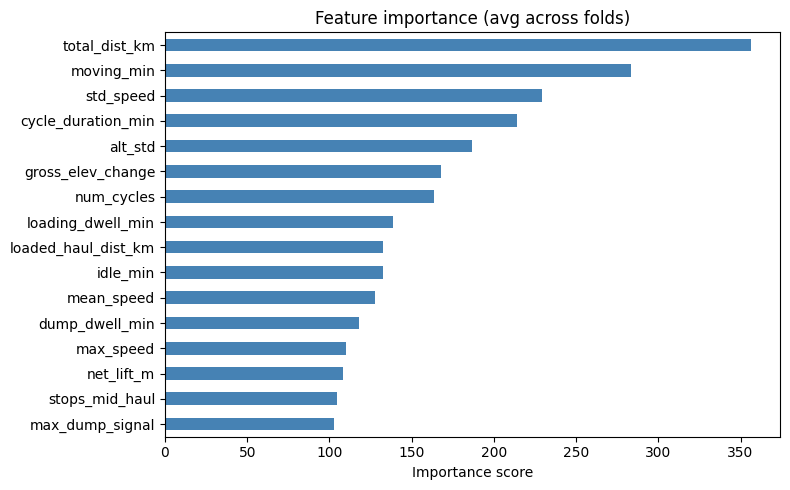

In [17]:
importances = np.mean([m.feature_importances_ for m in models], axis=0)
feat_imp    = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature importance (avg across folds)')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

## Cell 13 — Predict on Test Set & Export Submission

In [22]:
X_test     = daily_test[FEATURE_COLS].fillna(0).astype('float32')
test_preds = np.mean([m.predict(X_test) for m in models], axis=0)
test_preds = np.clip(test_preds, 0, 2000)

active_preds = pd.DataFrame({
    'vehicle': daily_test['vehicle'].astype(str),
    'op_day': daily_test['op_day'].astype(str),
    'active_fuel': test_preds
})

id_mapping_path = '/root/.cache/kagglehub/competitions/mindshift-analytics-haul-mark-challenge/id_mapping.csv'
df_id_map = pd.read_csv(id_mapping_path)

df_id_map['vehicle'] = df_id_map['vehicle'].astype(str)
df_id_map['op_day'] = df_id_map['date'].astype(str)

submission = df_id_map.merge(active_preds, on=['vehicle', 'op_day'], how='left')

submission['predicted_fuel_litres'] = submission['active_fuel'].fillna(0.0)

submission[['id', 'predicted_fuel_litres']].to_csv(SUBMISSION_PATH, index=False)
print(f'Saved: {SUBMISSION_PATH}')
print(f"Total Rows: {len(submission)} (Should be 552)")
print(f"Number of Exact Zeros: {(submission['predicted_fuel_litres'] == 0).sum()}")
print(submission[['id','predicted_fuel_litres']].head(10))

Saved: submission.csv
Total Rows: 552 (Should be 552)
Number of Exact Zeros: 211
   id  predicted_fuel_litres
0   0             261.382125
1   1             144.633623
2   2             137.472729
3   3             206.007900
4   4              92.464352
5   5               0.000000
6   6              39.956656
7   7               0.000000
8   8               0.000000
9   9              67.942326


## Cell 14 — Sanity Check Plots

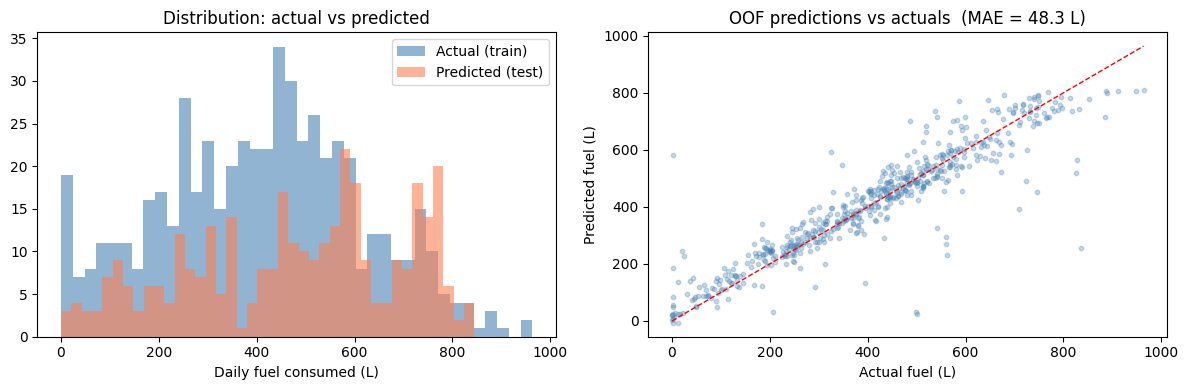

Prediction summary:
count    343.000000
mean     477.072139
std      218.215003
min        0.000000
25%      304.590762
50%      505.956612
75%      646.220988
max      844.443331
dtype: float64


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train.values, bins=40, alpha=0.6, label='Actual (train)',   color='steelblue')
axes[0].hist(test_preds,     bins=40, alpha=0.6, label='Predicted (test)', color='coral')
axes[0].set_xlabel('Daily fuel consumed (L)')
axes[0].set_title('Distribution: actual vs predicted')
axes[0].legend()

axes[1].scatter(y_train.values, oof_preds, alpha=0.3, s=10, color='steelblue')
mn, mx = float(y_train.min()), float(y_train.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[1].set_xlabel('Actual fuel (L)')
axes[1].set_ylabel('Predicted fuel (L)')
axes[1].set_title(f'OOF predictions vs actuals  (MAE = {overall_mae:.1f} L)')

plt.tight_layout()
plt.show()

print('Prediction summary:')
print(pd.Series(test_preds).describe())

In [24]:
# paste the output of all three of these
print("=== Feature Importance (top 5) ===")
print(feat_imp.tail(5))

print("\n=== OOF MAE ===")
print(f"MAE: {overall_mae:.2f} L")
print(f"Mean daily fuel: {float(y_train.mean()):.1f} L")
print(f"Error %: {100*overall_mae/float(y_train.mean()):.1f}%")

print("\n=== Submission sample ===")
print(submission[['id','predicted_fuel_litres']].head(10))

print("\n=== Prediction distribution ===")
print(pd.Series(test_preds).describe())

=== Feature Importance (top 5) ===
alt_std               186.6
cycle_duration_min    213.8
std_speed             229.4
moving_min            283.2
total_dist_km         356.2
dtype: float64

=== OOF MAE ===
MAE: 48.32 L
Mean daily fuel: 410.6 L
Error %: 11.8%

=== Submission sample ===
   id  predicted_fuel_litres
0   0             261.382125
1   1             144.633623
2   2             137.472729
3   3             206.007900
4   4              92.464352
5   5               0.000000
6   6              39.956656
7   7               0.000000
8   8               0.000000
9   9              67.942326

=== Prediction distribution ===
count    343.000000
mean     477.072139
std      218.215003
min        0.000000
25%      304.590762
50%      505.956612
75%      646.220988
max      844.443331
dtype: float64


In [25]:
print((pd.Series(test_preds) < 10).sum(), 'predictions below 10L')
print(daily_test[pd.Series(test_preds) < 10][['vehicle','op_day']])

2 predictions below 10L
     vehicle      op_day
237  Dump036  2026-01-20
326  Dump043  2026-01-22


In [ ]:
from google.colab import files
files.download('submission.csv')